# GNN OpenNeuro → test externo en Neurocon

Notebook para entrenar la GNN con grafos de conectividad funcional ya generados y evaluar el modelo usando **Neurocon como conjunto de test externo**, aplicando la técnica de leave-one-out.

La idea del experimento es:
- usar grafos de OpenNeuro para entrenamiento/evaluación;
- reservar Neurocon para test;
- filtrar matrices 116x116;
- aplicar la configuración final de la red neuronal.

## 0. Imports

Se cargan las librerías necesarias para manejar rutas, matrices, tablas, métricas, PyTorch y PyTorch Geometric.

In [40]:
from __future__ import annotations

from pathlib import Path
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_max_pool, global_mean_pool


## 1. Hiperparámetros

Configuración final utilizada para entrenar la red neuronal de grafos.

In [41]:
EPOCHS = 100
PACIENCIA = 10
LEARNING_RATE = 0.0005
DECAY = 0.0001
USAR_ABSOLUTO = False
K_VECINOS = 20
HIDDEN_DIM = 16
DROPOUT = 0.6
UMBRAL = 0.5
BATCH_SIZE = 32
SEMILLA = 168

print(f"EPOCHS = {EPOCHS}")
print(f"PACIENCIA = {PACIENCIA}")
print(f"LEARNING_RATE = {LEARNING_RATE}")
print(f"DECAY = {DECAY}")
print(f"USAR_ABSOLUTO = {USAR_ABSOLUTO}")
print(f"K_VECINOS = {K_VECINOS}")
print(f"HIDDEN_DIM = {HIDDEN_DIM}")
print(f"DROPOUT = {DROPOUT}")
print(f"UMBRAL = {UMBRAL}")
print(f"BATCH_SIZE = {BATCH_SIZE}")
print(f"SEMILLA = {SEMILLA}")


EPOCHS = 100
PACIENCIA = 10
LEARNING_RATE = 0.0005
DECAY = 0.0001
USAR_ABSOLUTO = False
K_VECINOS = 20
HIDDEN_DIM = 16
DROPOUT = 0.6
UMBRAL = 0.5
BATCH_SIZE = 32
SEMILLA = 168


## 2. Rutas de los grafos

Se indican las carpetas donde están guardadas las matrices de conectividad y los grafos ya generados.

In [42]:
RAIZ_DATOS = Path("./a")
CARPETA_CONTROL = RAIZ_DATOS / "graphs_threshold05" / "parkinson_control"
CARPETA_PATIENT = RAIZ_DATOS / "graphs_threshold05" / "parkinson_patient"

print("Carpeta control:", CARPETA_CONTROL)
print("Carpeta patient:", CARPETA_PATIENT)


Carpeta control: a\graphs_threshold05\parkinson_control
Carpeta patient: a\graphs_threshold05\parkinson_patient


## 3. Funciones auxiliares de carga e identificación

Estas funciones fijan la semilla, cargan matrices `.npz`, extraen el identificador de cada sujeto e identifican el dataset de origen.

In [43]:
def fijar_semilla(semilla: int) -> None:
    np.random.seed(semilla)
    random.seed(semilla)
    torch.manual_seed(semilla)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(semilla)


def cargar_matriz_desde_npz(ruta_npz: Path) -> np.ndarray:
    contenido = np.load(ruta_npz, allow_pickle=True)
    claves_preferidas = ["matriz", "connectivity", "conn", "fc", "arr_0"]

    matriz = None
    for clave in claves_preferidas:
        if clave in contenido.files and contenido[clave].ndim == 2:
            matriz = contenido[clave]
            break

    if matriz is None:
        for clave in contenido.files:
            if contenido[clave].ndim == 2:
                matriz = contenido[clave]
                break

    if matriz is None:
        raise ValueError(f"No se encontró ninguna matriz 2D válida en {ruta_npz}")

    return np.asarray(matriz, dtype=np.float32)


def normalizar_subject_id(subject_id: str) -> str:
    sid = str(subject_id).strip()
    sid = sid.replace("\\", "/")
    if sid.endswith("/"):
        sid = sid[:-1]
    return sid


def extraer_subject_id_desde_carpeta(carpeta: Path) -> str:
    nombre = carpeta.name
    if "__" in nombre:
        for parte in nombre.split("__"):
            if parte.startswith("sub-") or parte.startswith("ds"):
                return parte
    return nombre


def asignar_dataset_origen(subject_id: str, folder_name: str = "") -> str:
    sid = normalizar_subject_id(subject_id).lower()
    carpeta = str(folder_name).lower()

    if "ds005892" in sid or "ds005892" in carpeta:
        return "ds005892"
    if "ds004718" in sid or "ds004718" in carpeta:
        return "ds004718"
    if "ds004392" in sid or "ds004392" in carpeta:
        return "ds004392"
    if "neurocon" in sid or "neurocon" in carpeta:
        return "Neurocon"
    if sid.startswith("sub-control03") or sid.startswith("sub-patient03"):
        return "Neurocon"
    if sid.startswith("sub-mjf"):
        return "ds005892"
    if sid.startswith("sub-hk"):
        return "ds004718"
    if sid.startswith("sub-02") or sid.startswith("sub-2"):
        return "ds004392"

    return "desconocido"


def es_sujeto_test(subject_id: str, folder_name: str = "") -> bool:
    sid = normalizar_subject_id(subject_id).lower()
    carpeta = str(folder_name).lower()
    return (
        sid.startswith("neurocon")
        or carpeta.startswith("neurocon")
        or "neurocon" in sid
        or "neurocon" in carpeta
    )


## 4. Crear tabla de muestras

Se recorren las carpetas de controles y pacientes, localizando cada `connectivity_matrix_fmri.npz` y guardando su etiqueta.

In [44]:
def crear_tabla_muestras() -> pd.DataFrame:
    filas = []

    for carpeta_raiz, label, clase in [
        (CARPETA_CONTROL, 0, "control"),
        (CARPETA_PATIENT, 1, "patient"),
    ]:
        for carpeta_sujeto in sorted(carpeta_raiz.glob("*")):
            if not carpeta_sujeto.is_dir():
                continue

            ruta_npz = carpeta_sujeto / "connectivity_matrix_fmri.npz"
            if not ruta_npz.exists():
                continue

            subject_id = extraer_subject_id_desde_carpeta(carpeta_sujeto)
            filas.append(
                {
                    "subject_id": subject_id,
                    "subject_id_base": normalizar_subject_id(subject_id),
                    "folder_name": carpeta_sujeto.name,
                    "label": label,
                    "clase": clase,
                    "dataset_origen": asignar_dataset_origen(subject_id, carpeta_sujeto.name),
                    "es_test": es_sujeto_test(subject_id, carpeta_sujeto.name),
                    "ruta_npz": str(ruta_npz),
                }
            )

    tabla = pd.DataFrame(filas)

    if tabla.empty:
        raise ValueError("No se ha encontrado ningún archivo connectivity_matrix_fmri.npz")

    return tabla


## 5. Filtrado, balanceo y división train/eval/test

Se filtran las matrices 116x116, se balancean las muestras por dataset y se deja Neurocon como test.

In [45]:
def filtrar_matrices_tamano_fijo(
    tabla_muestras: pd.DataFrame,
    tamano_objetivo=(116, 116),
) -> pd.DataFrame:
    filas_validas = []

    for _, fila in tabla_muestras.iterrows():
        ruta_npz = Path(fila["ruta_npz"])
        matriz = cargar_matriz_desde_npz(ruta_npz)

        if matriz.shape == tamano_objetivo:
            nueva_fila = fila.to_dict()
            nueva_fila["forma_matriz"] = matriz.shape
            filas_validas.append(nueva_fila)

    tabla_filtrada = pd.DataFrame(filas_validas)

    if tabla_filtrada.empty:
        raise ValueError(f"No se encontraron matrices con forma {tamano_objetivo}")

    return tabla_filtrada


def dividir_dataset(tabla_filtrada: pd.DataFrame, semilla: int = 42):
    tabla = tabla_filtrada.copy().reset_index(drop=True)

    tabla_test = tabla[tabla["es_test"]].copy().reset_index(drop=True)
    tabla_train_eval = tabla[~tabla["es_test"]].copy().reset_index(drop=True)

    if tabla_train_eval.empty:
        raise ValueError("No hay muestras para train/eval tras separar el conjunto de test Neurocon")

    tabla_train_eval.loc[:, "stratify_col"] = tabla_train_eval["label"].astype(str)

    try:
        tabla_train_suj, tabla_eval_suj = train_test_split(
            tabla_train_eval,
            test_size=0.20,
            random_state=semilla,
            stratify=tabla_train_eval["stratify_col"],
        )
    except ValueError:
        tabla_train_suj, tabla_eval_suj = train_test_split(
            tabla_train_eval,
            test_size=0.20,
            random_state=semilla,
            shuffle=True,
        )

    tabla_train_suj = tabla_train_suj.drop(columns=["stratify_col"], errors="ignore").copy()
    tabla_eval_suj = tabla_eval_suj.drop(columns=["stratify_col"], errors="ignore").copy()

    train_ids = set(tabla_train_suj["subject_id_base"])
    eval_ids = set(tabla_eval_suj["subject_id_base"])
    test_ids = set(tabla_test["subject_id_base"])

    tabla_train = tabla[tabla["subject_id_base"].isin(train_ids)].copy().reset_index(drop=True)
    tabla_eval = tabla[tabla["subject_id_base"].isin(eval_ids)].copy().reset_index(drop=True)
    tabla_test = tabla[tabla["subject_id_base"].isin(test_ids)].copy().reset_index(drop=True)

    return tabla_train, tabla_eval, tabla_test


def balancear_por_dataset(tabla_filtrada: pd.DataFrame, semilla: int = 42) -> pd.DataFrame:
    '''
    Balancear muestras por dataset dentro de cada clase.

    Mantiene la distribución:
    - Control: 13 de cada dataset (ds004718, Neurocon, ds005892)
    - Patient: 25 de cada dataset (ds004392, Neurocon, ds005892)
    '''
    rng = np.random.RandomState(semilla)

    distribucion_objetivo = {
        "control": {
            "ds004718": 13,
            "Neurocon": 13,
            "ds005892": 13,
        },
        "patient": {
            "ds004392": 25,
            "Neurocon": 25,
            "ds005892": 25,
        },
    }

    filas_balanceadas = []

    for clase in ["control", "patient"]:
        sub_tabla = tabla_filtrada[tabla_filtrada["clase"] == clase].copy()

        for dataset, n_objetivo in distribucion_objetivo[clase].items():
            sub_dataset = sub_tabla[sub_tabla["dataset_origen"] == dataset].copy()
            n_disponible = len(sub_dataset)

            if n_disponible == 0:
                print(f"⚠ No hay muestras de {clase}/{dataset}")
                continue

            if n_disponible < n_objetivo:
                print(f"⚠ Solo hay {n_disponible} de {clase}/{dataset} (se necesitan {n_objetivo})")
                filas_balanceadas.extend(sub_dataset.to_dict("records"))
            else:
                indices_seleccionados = rng.choice(n_disponible, size=n_objetivo, replace=False)
                filas_balanceadas.extend(sub_dataset.iloc[indices_seleccionados].to_dict("records"))

    tabla_balanceada = pd.DataFrame(filas_balanceadas).reset_index(drop=True)
    return tabla_balanceada


## 6. Conversión de matrices a grafos

Se limpian las matrices de conectividad, se crean las features de los nodos y se generan las aristas usando los `K_VECINOS` más conectados.

In [46]:
def limpiar_matriz(matriz: np.ndarray, usar_absoluto: bool = False) -> np.ndarray:
    matriz = np.nan_to_num(matriz, nan=0.0, posinf=0.0, neginf=0.0)
    matriz = (matriz + matriz.T) / 2.0
    np.fill_diagonal(matriz, 0.0)

    if usar_absoluto:
        matriz = np.abs(matriz)
    else:
        matriz[matriz < 0] = 0.0

    return matriz.astype(np.float32)


def construir_features_nodo(matriz: np.ndarray) -> np.ndarray:
    return matriz.astype(np.float32)


def construir_aristas_desde_matriz(matriz: np.ndarray, k_vecinos: int = 10):
    num_nodos = matriz.shape[0]
    k_vecinos = min(k_vecinos, num_nodos - 1)
    mascara = np.zeros_like(matriz, dtype=bool)

    for i in range(num_nodos):
        fila = matriz[i].copy()
        fila[i] = -np.inf
        indices_topk = np.argpartition(fila, -k_vecinos)[-k_vecinos:]
        indices_topk = indices_topk[fila[indices_topk] > 0]
        mascara[i, indices_topk] = True

    mascara = np.logical_or(mascara, mascara.T)
    origen, destino = np.where(mascara)
    pesos = matriz[origen, destino].astype(np.float32)

    edge_index = torch.tensor(np.vstack([origen, destino]), dtype=torch.long)
    edge_weight = torch.tensor(pesos, dtype=torch.float32)

    return edge_index, edge_weight


def crear_grafo_desde_fila(
    fila_tabla,
    usar_absoluto: bool = False,
    k_vecinos: int = 10,
) -> Data:
    ruta_npz = Path(fila_tabla["ruta_npz"])
    label = int(fila_tabla["label"])
    subject_id = str(fila_tabla["subject_id"])

    matriz = cargar_matriz_desde_npz(ruta_npz)
    matriz = limpiar_matriz(matriz, usar_absoluto=usar_absoluto)

    x = construir_features_nodo(matriz)
    edge_index, edge_weight = construir_aristas_desde_matriz(matriz, k_vecinos=k_vecinos)

    data = Data(
        x=torch.tensor(x, dtype=torch.float32),
        edge_index=edge_index,
        edge_weight=edge_weight,
        y=torch.tensor([label], dtype=torch.float32),
    )

    data.subject_id = subject_id
    data.folder_name = str(fila_tabla.get("folder_name", ""))
    data.dataset_origen = str(fila_tabla.get("dataset_origen", "desconocido"))
    data.ruta_npz = str(ruta_npz)
    data.num_nodos_original = matriz.shape[0]

    return data


def convertir_tabla_a_lista_grafos(
    tabla: pd.DataFrame,
    usar_absoluto: bool = False,
    k_vecinos: int = 10,
):
    return [
        crear_grafo_desde_fila(
            fila,
            usar_absoluto=usar_absoluto,
            k_vecinos=k_vecinos,
        )
        for _, fila in tabla.iterrows()
    ]


def normalizar_features_grafos(train_graphs, val_graphs, test_graphs):
    x_train = torch.cat([g.x for g in train_graphs], dim=0)
    media = x_train.mean(dim=0, keepdim=True)
    desviacion = torch.clamp(x_train.std(dim=0, keepdim=True), min=1e-6)

    for lista in (train_graphs, val_graphs, test_graphs):
        for grafo in lista:
            grafo.x = (grafo.x - media) / desviacion

    return train_graphs, val_graphs, test_graphs


## 7. Modelo GCN binario

Se define una red GCN con tres capas convolucionales y pooling global medio/máximo para clasificar cada grafo completo.

In [47]:
class RedGCNBinaria(nn.Module):
    def __init__(self, num_features_entrada: int, hidden_dim: int = 32, dropout: float = 0.4):
        super().__init__()

        self.conv1 = GCNConv(num_features_entrada, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim // 2)

        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        x = data.x
        edge_index = data.edge_index
        edge_weight = data.edge_weight
        batch = data.batch

        x = self.conv1(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.conv3(x, edge_index, edge_weight=edge_weight)
        x = F.relu(x)

        x_mean = global_mean_pool(x, batch)
        x_max = global_max_pool(x, batch)
        x = torch.cat([x_mean, x_max], dim=1)

        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)

        logits = self.fc2(x).squeeze(1)
        return logits


## 8. Funciones de entrenamiento y evaluación

Se calculan métricas, se entrena cada época, se evalúa el modelo y se aplica early stopping sobre el conjunto de validación.

In [48]:
def _calcular_metricas(y_reales: np.ndarray, y_probs: np.ndarray, umbral: float):
    y_predichas = (y_probs >= umbral).astype(int)

    return {
        "accuracy": accuracy_score(y_reales, y_predichas),
        "precision": precision_score(y_reales, y_predichas, zero_division=0),
        "recall": recall_score(y_reales, y_predichas, zero_division=0),
        "f1": f1_score(y_reales, y_predichas, zero_division=0),
        "auc": roc_auc_score(y_reales, y_probs) if len(np.unique(y_reales)) > 1 else np.nan,
        "y_predichas": y_predichas,
    }


def entrenar_una_epoca(modelo, loader, optimizer, criterio, device, umbral):
    modelo.train()
    perdidas = []
    y_reales = []
    y_probs = []

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        logits = modelo(batch)
        y = batch.y.view(-1)
        loss = criterio(logits, y)

        loss.backward()
        optimizer.step()

        perdidas.append(loss.item())

        probs = torch.sigmoid(logits)
        y_reales.extend(y.detach().cpu().numpy())
        y_probs.extend(probs.detach().cpu().numpy())

    y_reales = np.array(y_reales)
    y_probs = np.array(y_probs)

    metricas = _calcular_metricas(y_reales, y_probs, umbral)
    metricas["loss"] = float(np.mean(perdidas))

    return metricas


@torch.no_grad()
def evaluar_modelo(modelo, loader, criterio, device, umbral):
    modelo.eval()
    perdidas = []
    y_reales = []
    y_probs = []

    for batch in loader:
        batch = batch.to(device)

        logits = modelo(batch)
        y = batch.y.view(-1)
        loss = criterio(logits, y)

        perdidas.append(loss.item())

        probs = torch.sigmoid(logits)
        y_reales.extend(y.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

    y_reales = np.array(y_reales)
    y_probs = np.array(y_probs)

    metricas = _calcular_metricas(y_reales, y_probs, umbral)
    metricas["loss"] = float(np.mean(perdidas))
    metricas["y_reales"] = y_reales
    metricas["y_probs"] = y_probs

    return metricas


def convertir_lista_a_loader(grafos, batch_size: int, shuffle: bool) -> DataLoader:
    return DataLoader(grafos, batch_size=batch_size, shuffle=shuffle)


## 9. Resúmenes, guardado y gráficas

Funciones para imprimir distribuciones, guardar resultados y dibujar las curvas de entrenamiento.

In [49]:
def _resumen_clases(tabla: pd.DataFrame) -> pd.DataFrame:
    conteos = tabla["clase"].value_counts().reindex(["control", "patient"], fill_value=0)
    total = int(conteos.sum())

    resumen = pd.DataFrame(
        {
            "n": conteos.astype(int),
            "proporcion": (conteos / total if total else 0.0).astype(float),
        }
    )
    resumen.index.name = "clase"

    return resumen


def _imprimir_resumen_clases(titulo: str, tabla: pd.DataFrame) -> None:
    resumen = _resumen_clases(tabla)
    total = int(len(tabla))

    print(titulo)
    print(f" Total: {total}")

    for clase in ["control", "patient"]:
        n = int(resumen.loc[clase, "n"])
        prop = float(resumen.loc[clase, "proporcion"])
        print(f" {clase.capitalize():8s} -> n={n} | proporcion={prop:.4f}")

    print()


def imprimir_resumen_split(
    tabla_train: pd.DataFrame,
    tabla_eval: pd.DataFrame,
    tabla_test: pd.DataFrame,
) -> None:
    print("Resumen de splits:")
    _imprimir_resumen_clases(" Train", tabla_train)
    _imprimir_resumen_clases(" Eval", tabla_eval)
    _imprimir_resumen_clases(" Test", tabla_test)


def imprimir_cuentas_por_dataset(tabla_filtrada: pd.DataFrame) -> None:
    print("Cuentas por dataset tras filtrado 116x116:")
    grouped = tabla_filtrada.groupby(["clase", "dataset_origen"]).size().reset_index(name="n")

    if grouped.empty:
        print(" No hay muestras.")
        return

    for clase in ["control", "patient"]:
        sub = grouped[grouped["clase"] == clase]
        print(f" {clase.capitalize()}:")

        if sub.empty:
            print(" (ninguno)")
            continue

        for _, row in sub.sort_values("n", ascending=False).iterrows():
            print(f" {row['dataset_origen']}: {int(row['n'])}")

    print()


def guardar_predicciones(test_graphs, resultado, tabla_test: pd.DataFrame) -> None:
    '''Guarda las predicciones individuales en un CSV.'''
    subject_ids = [g.subject_id for g in test_graphs]
    y_reales = resultado["test"]["y_reales"]
    y_probs = resultado["test"]["y_probs"]
    y_predichas = resultado["test"]["y_predichas"]

    df_predicciones = pd.DataFrame(
        {
            "subject_id": subject_ids,
            "dataset_origen": [
                tabla_test.loc[tabla_test["subject_id"] == sid, "dataset_origen"].values[0]
                if sid in tabla_test["subject_id"].values
                else "unknown"
                for sid in subject_ids
            ],
            "label_real": y_reales.astype(int),
            "prediccion": y_predichas.astype(int),
            "probabilidad": y_probs.astype(np.float32),
        }
    )

    ruta_predicciones = Path("predicciones_test.csv")
    df_predicciones.to_csv(ruta_predicciones, index=False)
    print(f"Predicciones guardadas en: {ruta_predicciones.absolute()}")


def guardar_resumen_resultados(
    resultado,
    tabla_train: pd.DataFrame,
    tabla_eval: pd.DataFrame,
    tabla_test: pd.DataFrame,
) -> None:
    '''Guarda un resumen de los resultados con hiperparámetros y métricas.'''
    resumen_datos = {
        "learning_rate": [LEARNING_RATE],
        "dropout": [DROPOUT],
        "hidden_dim": [HIDDEN_DIM],
        "k_vecinos": [K_VECINOS],
        "epochs": [EPOCHS],
        "paciencia": [PACIENCIA],
        "decay": [DECAY],
        "batch_size": [BATCH_SIZE],
        "usar_absoluto": [USAR_ABSOLUTO],
        "umbral": [UMBRAL],
        "n_train": [len(tabla_train)],
        "n_eval": [len(tabla_eval)],
        "n_test": [len(tabla_test)],
        "test_accuracy": [resultado["test"]["accuracy"]],
        "test_precision": [resultado["test"]["precision"]],
        "test_recall": [resultado["test"]["recall"]],
        "test_f1": [resultado["test"]["f1"]],
        "test_auc": [resultado["test"]["auc"]],
        "eval_accuracy": [resultado["val"]["accuracy"]],
        "eval_f1": [resultado["val"]["f1"]],
        "eval_auc": [resultado["val"]["auc"]],
        "train_accuracy": [resultado["train"]["accuracy"]],
        "train_f1": [resultado["train"]["f1"]],
        "train_auc": [resultado["train"]["auc"]],
    }

    df_resumen = pd.DataFrame(resumen_datos)
    ruta_resumen = Path("resumen_resultados.csv")
    df_resumen.to_csv(ruta_resumen, index=False)
    print(f"Resumen guardado en: {ruta_resumen.absolute()}")


def guardar_historial_entrenamiento(historial) -> None:
    '''Guarda el historial por época para poder reutilizarlo en gráficas o análisis posterior.'''
    df_historial = pd.DataFrame(historial)
    ruta_historial = Path("historial_entrenamiento.csv")
    df_historial.to_csv(ruta_historial, index=False)
    print(f"Historial guardado en: {ruta_historial.absolute()}")


def dibujar_curva(historial, clave_train, clave_val, titulo, ylabel, nombre_archivo):
    '''Dibuja una curva de entrenamiento/validación y la guarda a disco.'''
    plt.figure(figsize=(8, 5))
    plt.plot(historial[clave_train], label=f"Train {ylabel}")
    plt.plot(historial[clave_val], label=f"Val {ylabel}")
    plt.title(titulo)
    plt.xlabel("Época")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(nombre_archivo, dpi=150)
    plt.show()


## 10. Entrenar modelo

Se crea el modelo, se aplica el peso de clase positiva y se entrena con early stopping.

In [50]:
def entrenar_modelo(train_graphs, val_graphs, test_graphs, device):
    train_loader = convertir_lista_a_loader(train_graphs, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = convertir_lista_a_loader(val_graphs, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = convertir_lista_a_loader(test_graphs, batch_size=BATCH_SIZE, shuffle=False)

    num_features_entrada = train_graphs[0].x.shape[1]
    modelo = RedGCNBinaria(
        num_features_entrada=num_features_entrada,
        hidden_dim=HIDDEN_DIM,
        dropout=DROPOUT,
    ).to(device)

    etiquetas_train = np.array([int(g.y.item()) for g in train_graphs])
    num_positivos = max(int((etiquetas_train == 1).sum()), 1)
    num_negativos = int((etiquetas_train == 0).sum())

    peso_clase_positiva = torch.tensor(
        [num_negativos / num_positivos],
        dtype=torch.float32,
    ).to(device)

    criterio = nn.BCEWithLogitsLoss(pos_weight=peso_clase_positiva)
    optimizer = torch.optim.Adam(
        modelo.parameters(),
        lr=LEARNING_RATE,
        weight_decay=DECAY,
    )

    mejor_val_f1 = float("-inf")
    mejor_val_auc = float("-inf")
    mejor_estado_modelo = None
    epocas_sin_mejora = 0

    historial = {
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "train_f1": [],
        "train_auc": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_f1": [],
        "val_auc": [],
    }

    for epoca in range(1, EPOCHS + 1):
        metricas_train = entrenar_una_epoca(modelo, train_loader, optimizer, criterio, device, UMBRAL)
        metricas_val = evaluar_modelo(modelo, val_loader, criterio, device, UMBRAL)

        historial["epoch"].append(epoca)
        historial["train_loss"].append(metricas_train["loss"])
        historial["train_accuracy"].append(metricas_train["accuracy"])
        historial["train_f1"].append(metricas_train["f1"])
        historial["train_auc"].append(metricas_train["auc"])
        historial["val_loss"].append(metricas_val["loss"])
        historial["val_accuracy"].append(metricas_val["accuracy"])
        historial["val_f1"].append(metricas_val["f1"])
        historial["val_auc"].append(metricas_val["auc"])

        val_f1_actual = metricas_val["f1"]
        val_auc_actual = metricas_val["auc"]

        if np.isnan(val_auc_actual):
            val_auc_actual = float("-inf")

        mejora_f1 = val_f1_actual > mejor_val_f1 + 1e-4
        empate_f1 = abs(val_f1_actual - mejor_val_f1) <= 1e-4
        mejora_auc_en_empate = val_auc_actual > mejor_val_auc + 1e-4

        if mejora_f1 or (empate_f1 and mejora_auc_en_empate):
            mejor_val_f1 = val_f1_actual
            mejor_val_auc = val_auc_actual
            mejor_estado_modelo = copy.deepcopy(modelo.state_dict())
            epocas_sin_mejora = 0
        else:
            epocas_sin_mejora += 1

        print(
            f"Epoca {epoca:03d} | "
            f"train_loss={metricas_train['loss']:.4f} | train_f1={metricas_train['f1']:.4f} | "
            f"val_loss={metricas_val['loss']:.4f} | val_f1={metricas_val['f1']:.4f} | val_auc={metricas_val['auc']:.4f}"
        )

        if epocas_sin_mejora >= PACIENCIA:
            print(f"Early stopping activado en epoca {epoca}.")
            break

    if mejor_estado_modelo is not None:
        modelo.load_state_dict(mejor_estado_modelo)

    metricas_train_final = evaluar_modelo(modelo, train_loader, criterio, device, UMBRAL)
    metricas_val_final = evaluar_modelo(modelo, val_loader, criterio, device, UMBRAL)
    metricas_test = evaluar_modelo(modelo, test_loader, criterio, device, UMBRAL)

    return {
        "modelo": modelo,
        "criterio": criterio,
        "historial": historial,
        "train": metricas_train_final,
        "val": metricas_val_final,
        "test": metricas_test,
        "cm": confusion_matrix(metricas_test["y_reales"], metricas_test["y_predichas"]),
        "reporte": classification_report(
            metricas_test["y_reales"],
            metricas_test["y_predichas"],
            zero_division=0,
        ),
    }


## 11. Preparación del experimento

Se fija la semilla, se selecciona el dispositivo y se cargan las muestras disponibles.

La semilla se utiliza para que la división se haga siempre de forma aleatoria pero con el mismo reparto de archivos, y se pueda probar siempre sobre la misma división. Por tanto, para comprobar la fiabilidad de los resultados, hay que aplicar cross-validation.

In [51]:
fijar_semilla(SEMILLA)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Dispositivo: {DEVICE}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print()

print("Hiperparámetros:")
print(f" EPOCHS={EPOCHS}")
print(f" PACIENCIA={PACIENCIA}")
print(f" LEARNING_RATE={LEARNING_RATE}")
print(f" DECAY={DECAY}")
print(f" USAR_ABSOLUTO={USAR_ABSOLUTO}")
print(f" K_VECINOS={K_VECINOS}")
print(f" HIDDEN_DIM={HIDDEN_DIM}")
print(f" DROPOUT={DROPOUT}")
print(f" UMBRAL={UMBRAL}")
print(f" BATCH_SIZE={BATCH_SIZE}")
print(f" SEMILLA={SEMILLA}")


Dispositivo: cpu
CUDA disponible: False

Hiperparámetros:
 EPOCHS=100
 PACIENCIA=10
 LEARNING_RATE=0.0005
 DECAY=0.0001
 USAR_ABSOLUTO=False
 K_VECINOS=20
 HIDDEN_DIM=16
 DROPOUT=0.6
 UMBRAL=0.5
 BATCH_SIZE=32
 SEMILLA=168


## 12. Carga, filtrado y balanceo de datos

Se cargan todas las muestras, se filtran matrices 116x116 y se aplica el balanceo por dataset definido en el script.

In [52]:
tabla_muestras = crear_tabla_muestras()
tabla_116 = filtrar_matrices_tamano_fijo(tabla_muestras, tamano_objetivo=(116, 116))

_imprimir_resumen_clases("Resumen tras filtrado 116x116", tabla_116)
imprimir_cuentas_por_dataset(tabla_116)

print("Aplicando balanceo por dataset...")
tabla_116 = balancear_por_dataset(tabla_116, semilla=SEMILLA)

print("Cuentas tras balanceo:")
imprimir_cuentas_por_dataset(tabla_116)


Resumen tras filtrado 116x116
 Total: 178
 Control  -> n=73 | proporcion=0.4101
 Patient  -> n=105 | proporcion=0.5899

Cuentas por dataset tras filtrado 116x116:
 Control:
 ds004718: 46
 Neurocon: 14
 ds005892: 13
 Patient:
 ds004392: 55
 Neurocon: 25
 ds005892: 25

Aplicando balanceo por dataset...
Cuentas tras balanceo:
Cuentas por dataset tras filtrado 116x116:
 Control:
 Neurocon: 13
 ds004718: 13
 ds005892: 13
 Patient:
 Neurocon: 25
 ds004392: 25
 ds005892: 25



## 13. División en train/eval/test

Se separa Neurocon como conjunto de test externo y el resto se divide en entrenamiento y evaluación.

In [53]:
tabla_train, tabla_eval, tabla_test = dividir_dataset(tabla_116, semilla=SEMILLA)
imprimir_resumen_split(tabla_train, tabla_eval, tabla_test)

print("Primeras muestras de train:")
display(tabla_train.head())

print("Primeras muestras de test:")
display(tabla_test.head())


Resumen de splits:
 Train
 Total: 60
 Control  -> n=21 | proporcion=0.3500
 Patient  -> n=39 | proporcion=0.6500

 Eval
 Total: 16
 Control  -> n=5 | proporcion=0.3125
 Patient  -> n=11 | proporcion=0.6875

 Test
 Total: 38
 Control  -> n=13 | proporcion=0.3421
 Patient  -> n=25 | proporcion=0.6579

Primeras muestras de train:


,subject_id,subject_id_base,folder_name,label,clase,dataset_origen,es_test,ruta_npz,forma_matriz
0,ds004718-sub-HK040-sub-HK040_task-rest_bold_de...,ds004718-sub-HK040-sub-HK040_task-rest_bold_de...,ds004718-sub-HK040-sub-HK040_task-rest_bold_de...,0,control,ds004718,False,a\graphs_threshold05\parkinson_control\ds00471...,"(116, 116)"
1,ds004718-sub-HK002-sub-HK002_task-rest_bold_de...,ds004718-sub-HK002-sub-HK002_task-rest_bold_de...,ds004718-sub-HK002-sub-HK002_task-rest_bold_de...,0,control,ds004718,False,a\graphs_threshold05\parkinson_control\ds00471...,"(116, 116)"
2,ds004718-sub-HK012-sub-HK012_task-rest_bold_de...,ds004718-sub-HK012-sub-HK012_task-rest_bold_de...,ds004718-sub-HK012-sub-HK012_task-rest_bold_de...,0,control,ds004718,False,a\graphs_threshold05\parkinson_control\ds00471...,"(116, 116)"
3,ds004718-sub-HK020-sub-HK020_task-rest_bold_de...,ds004718-sub-HK020-sub-HK020_task-rest_bold_de...,ds004718-sub-HK020-sub-HK020_task-rest_bold_de...,0,control,ds004718,False,a\graphs_threshold05\parkinson_control\ds00471...,"(116, 116)"
4,ds004718-sub-HK018-sub-HK018_task-rest_bold_de...,ds004718-sub-HK018-sub-HK018_task-rest_bold_de...,ds004718-sub-HK018-sub-HK018_task-rest_bold_de...,0,control,ds004718,False,a\graphs_threshold05\parkinson_control\ds00471...,"(116, 116)"


Primeras muestras de test:


,subject_id,subject_id_base,folder_name,label,clase,dataset_origen,es_test,ruta_npz,forma_matriz
0,neurocon-sub-control032024-sub-control032024_t...,neurocon-sub-control032024-sub-control032024_t...,neurocon-sub-control032024-sub-control032024_t...,0,control,Neurocon,True,a\graphs_threshold05\parkinson_control\neuroco...,"(116, 116)"
1,neurocon-sub-control032029-sub-control032029_t...,neurocon-sub-control032029-sub-control032029_t...,neurocon-sub-control032029-sub-control032029_t...,0,control,Neurocon,True,a\graphs_threshold05\parkinson_control\neuroco...,"(116, 116)"
2,neurocon-sub-control032021-sub-control032021_t...,neurocon-sub-control032021-sub-control032021_t...,neurocon-sub-control032021-sub-control032021_t...,0,control,Neurocon,True,a\graphs_threshold05\parkinson_control\neuroco...,"(116, 116)"
3,neurocon-sub-control032026-sub-control032026_t...,neurocon-sub-control032026-sub-control032026_t...,neurocon-sub-control032026-sub-control032026_t...,0,control,Neurocon,True,a\graphs_threshold05\parkinson_control\neuroco...,"(116, 116)"
4,neurocon-sub-control032028-sub-control032028_t...,neurocon-sub-control032028-sub-control032028_t...,neurocon-sub-control032028-sub-control032028_t...,0,control,Neurocon,True,a\graphs_threshold05\parkinson_control\neuroco...,"(116, 116)"


## 14. Construcción de grafos y normalización

Se convierten las matrices en objetos `Data` de PyTorch Geometric y se normalizan las features usando solo el conjunto de entrenamiento.

In [54]:
train_graphs = convertir_tabla_a_lista_grafos(
    tabla_train,
    usar_absoluto=USAR_ABSOLUTO,
    k_vecinos=K_VECINOS,
)
val_graphs = convertir_tabla_a_lista_grafos(
    tabla_eval,
    usar_absoluto=USAR_ABSOLUTO,
    k_vecinos=K_VECINOS,
)
test_graphs = convertir_tabla_a_lista_grafos(
    tabla_test,
    usar_absoluto=USAR_ABSOLUTO,
    k_vecinos=K_VECINOS,
)

train_graphs, val_graphs, test_graphs = normalizar_features_grafos(
    train_graphs,
    val_graphs,
    test_graphs,
)

print("Grafos train:", len(train_graphs))
print("Grafos eval :", len(val_graphs))
print("Grafos test :", len(test_graphs))
print("Nodos por grafo:", train_graphs[0].num_nodes)
print("Features por nodo:", train_graphs[0].x.shape[1])


Grafos train: 60
Grafos eval : 16
Grafos test : 38
Nodos por grafo: 116
Features por nodo: 116


## 15. Entrenamiento final

Se entrena la GNN con la configuración seleccionada y se guardan las métricas finales.

In [55]:
resultado = entrenar_modelo(train_graphs, val_graphs, test_graphs, DEVICE)
historial = resultado["historial"]


Epoca 001 | train_loss=0.6219 | train_f1=0.6588 | val_loss=0.4693 | val_f1=0.8148 | val_auc=0.5273
Epoca 002 | train_loss=0.5015 | train_f1=0.6742 | val_loss=0.4691 | val_f1=0.8148 | val_auc=0.5273
Epoca 003 | train_loss=0.5827 | train_f1=0.6742 | val_loss=0.4689 | val_f1=0.8148 | val_auc=0.5455
Epoca 004 | train_loss=0.5188 | train_f1=0.6588 | val_loss=0.4688 | val_f1=0.8148 | val_auc=0.5455
Epoca 005 | train_loss=0.4888 | train_f1=0.7500 | val_loss=0.4686 | val_f1=0.8148 | val_auc=0.5455
Epoca 006 | train_loss=0.5596 | train_f1=0.7174 | val_loss=0.4684 | val_f1=0.8148 | val_auc=0.5818
Epoca 007 | train_loss=0.5065 | train_f1=0.6977 | val_loss=0.4681 | val_f1=0.8148 | val_auc=0.6182
Epoca 008 | train_loss=0.5365 | train_f1=0.6341 | val_loss=0.4679 | val_f1=0.8148 | val_auc=0.6545
Epoca 009 | train_loss=0.4988 | train_f1=0.6914 | val_loss=0.4677 | val_f1=0.8148 | val_auc=0.6727
Epoca 010 | train_loss=0.5066 | train_f1=0.6914 | val_loss=0.4675 | val_f1=0.8462 | val_auc=0.6727
Epoca 011 

## 16. Resultados finales

Se muestran las métricas finales en train, eval y test, además de la matriz de confusión y el classification report.

In [56]:
print("Resultados finales:")
print(
    f"TRAIN -> Loss: {resultado['train']['loss']:.4f} | Acc: {resultado['train']['accuracy']:.4f} | "
    f"Recall: {resultado['train']['recall']:.4f} | F1: {resultado['train']['f1']:.4f} | AUC: {resultado['train']['auc']:.4f}"
)
print(
    f"EVAL  -> Loss: {resultado['val']['loss']:.4f} | Acc: {resultado['val']['accuracy']:.4f} | "
    f"Recall: {resultado['val']['recall']:.4f} | F1: {resultado['val']['f1']:.4f} | AUC: {resultado['val']['auc']:.4f}"
)
print(
    f"TEST  -> Loss: {resultado['test']['loss']:.4f} | Acc: {resultado['test']['accuracy']:.4f} | "
    f"Recall: {resultado['test']['recall']:.4f} | F1: {resultado['test']['f1']:.4f} | AUC: {resultado['test']['auc']:.4f}"
)

print("Matriz de confusión de test:")
print(resultado["cm"])

print("Classification report de test:")
print(resultado["reporte"])


Resultados finales:
TRAIN -> Loss: 0.4723 | Acc: 0.6667 | Recall: 0.7179 | F1: 0.7368 | AUC: 0.6777
EVAL  -> Loss: 0.4565 | Acc: 0.9375 | Recall: 1.0000 | F1: 0.9565 | AUC: 0.8182
TEST  -> Loss: 0.4291 | Acc: 0.7632 | Recall: 0.9200 | F1: 0.8364 | AUC: 0.7231
Matriz de confusión de test:
[[ 6  7]
 [ 2 23]]
Classification report de test:
              precision    recall  f1-score   support

         0.0       0.75      0.46      0.57        13
         1.0       0.77      0.92      0.84        25

    accuracy                           0.76        38
   macro avg       0.76      0.69      0.70        38
weighted avg       0.76      0.76      0.75        38



## 17. Visualización de resultados

Se representa la matriz de confusión del test y las curvas de accuracy, F1-score y AUC.

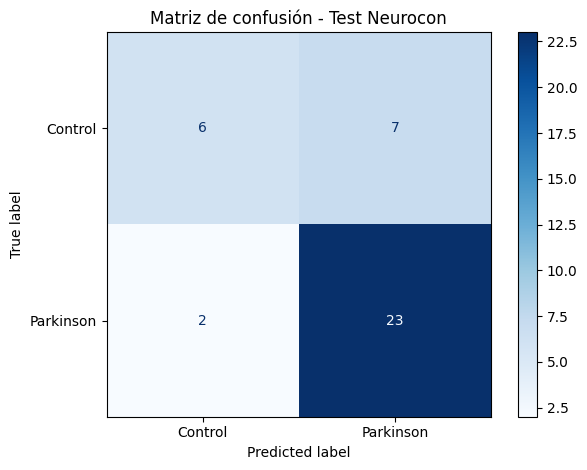

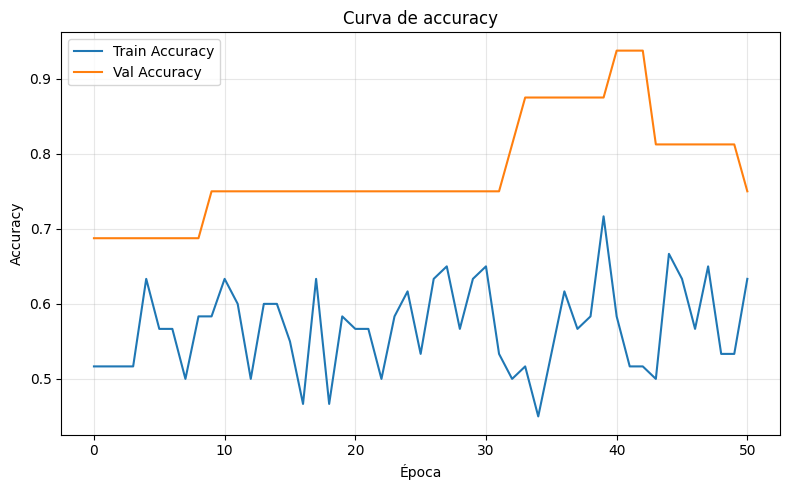

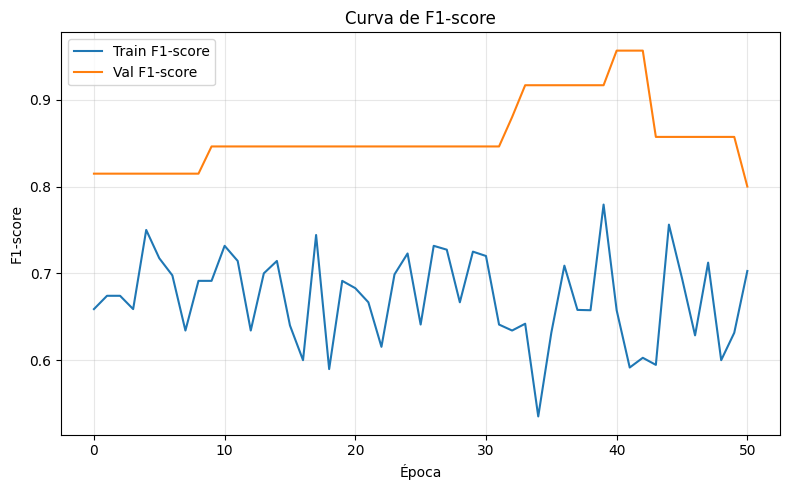

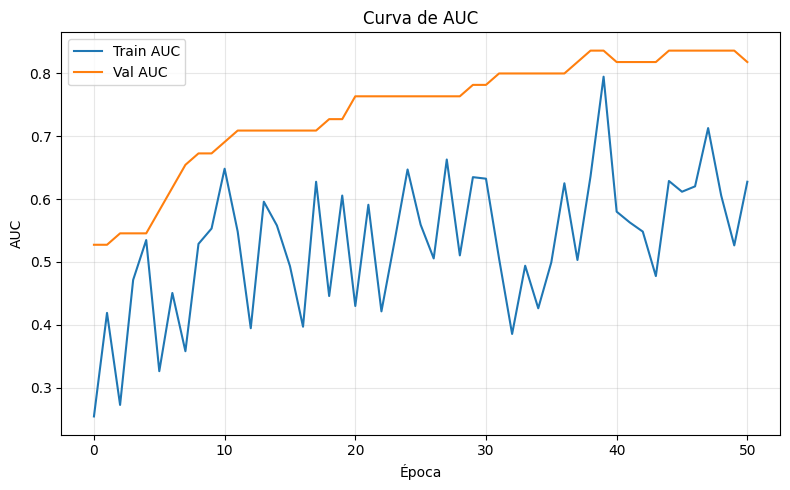

In [57]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=resultado["cm"],
    display_labels=["Control", "Parkinson"],
)
disp.plot(cmap="Blues")
plt.title("Matriz de confusión - Test Neurocon")
plt.tight_layout()
plt.show()

# Curva de accuracy
dibujar_curva(
    historial=historial,
    clave_train="train_accuracy",
    clave_val="val_accuracy",
    titulo="Curva de accuracy",
    ylabel="Accuracy",
    nombre_archivo="curva_accuracy_gcnn.png",
)

# Curva de F1-score
dibujar_curva(
    historial=historial,
    clave_train="train_f1",
    clave_val="val_f1",
    titulo="Curva de F1-score",
    ylabel="F1-score",
    nombre_archivo="curva_f1_gcnn.png",
)

# Curva de AUC
dibujar_curva(
    historial=historial,
    clave_train="train_auc",
    clave_val="val_auc",
    titulo="Curva de AUC",
    ylabel="AUC",
    nombre_archivo="curva_auc_gcnn.png",
)


## 18. Guardado de resultados

Se guardan el historial de entrenamiento, las predicciones individuales y un resumen con hiperparámetros y métricas.

In [58]:
guardar_historial_entrenamiento(historial)
guardar_predicciones(test_graphs, resultado, tabla_test)
guardar_resumen_resultados(resultado, tabla_train, tabla_eval, tabla_test)


Historial guardado en: c:\Users\david\OneDrive\Escritorio\5 UFV\TFG\a\mrigraph\historial_entrenamiento.csv
Predicciones guardadas en: c:\Users\david\OneDrive\Escritorio\5 UFV\TFG\a\mrigraph\predicciones_test.csv
Resumen guardado en: c:\Users\david\OneDrive\Escritorio\5 UFV\TFG\a\mrigraph\resumen_resultados.csv
